# 1D Single Layer FEM Verification

This notebook compares the 1D single layer FEM solver against the analytical Fourier-series solution for the uniform initial excess pore-pressure case.

Checks covered:

1. pore-pressure profiles at selected time snapshots
2. error metrics through time (RMSE, L2)
3. settlement history comparison
4. mesh-refinement convergence
5. time-step convergence


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os, sys
project_root = os.path.abspath(os.path.join('..'))
sys.path.insert(0, project_root)

from src.geotech_consolidation.models.terzaghi_1d.fem import Get_terzaghi1D_FEA
from src.geotech_consolidation.models.terzaghi_1d.analytical import Get_terzaghi1d_Analytical

sns.set_theme(style="whitegrid")

H = 5.0         
num = 50        
nodes = num + 1
load = 100.0        # (kPa)
Cv = 2e-7         # (m2/s)
Mv = 5e-4         # (m2/kN)
Final_time = (24 * 60 * 60) * 365   
time_steps = 1000
N_terms = 200

depth = np.linspace(0.0, H, nodes)
time_days = np.linspace(0.0, Final_time / (60 * 60 * 24), time_steps)
total_settlement = Mv * load * H


w_w = 9.81   # (kN/m³)
k = Cv * Mv * w_w

print(f"k  = {k:.2e} m/s ")
print(f"Total settlement = {total_settlement:.6f} m")

k  = 9.81e-10 m/s 
Total settlement = 0.250000 m


## FEM and Analytical Solutions

Both solvers run on the same depth and time grids so their outputs can be compared directly.


In [2]:
fem_settlement_hist, fem_udata, fem_settlement_profile = Get_terzaghi1D_FEA(H, num, load, Final_time, time_steps, Cv, 0.0, Mv, True)
analytical_cdata, analytical_udata, depth_a, time_a = Get_terzaghi1d_Analytical(H, num, load, Final_time, time_steps, Cv, N_terms)

## Error Through Time

RMSE and normalised L2 norm computed at each time step. The early-time spike is caused by the Fourier series Gibbs effect near the drained boundary and is not a solver error.


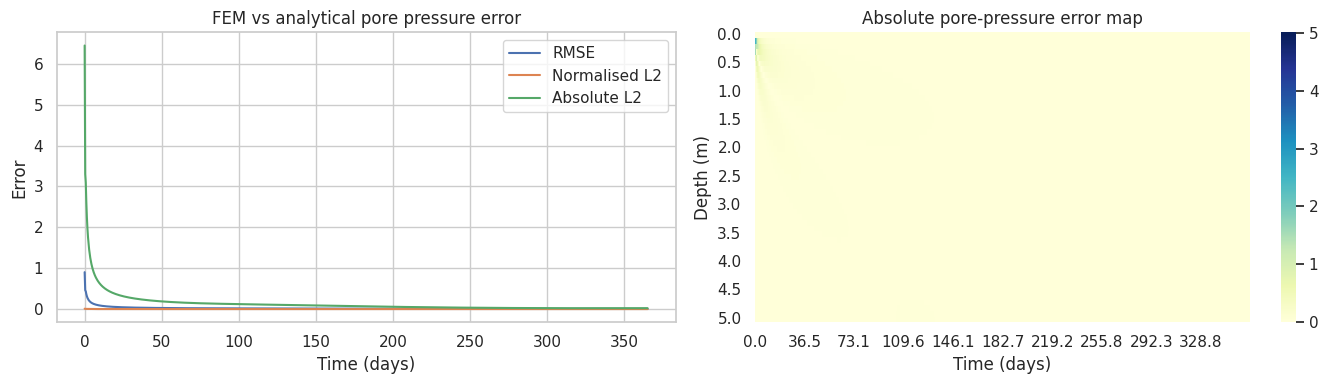

In [3]:
error   = fem_udata - analytical_udata
rmse    = np.sqrt((error**2).mean(axis=1))
num_l2  = (error**2).sum(axis=1)
den_l2  = (analytical_udata**2).sum(axis=1)
norm_l2 = np.sqrt(num_l2 / (den_l2 + 1e-12))
abs_l2  = np.sqrt(num_l2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(time_days, rmse,    label="RMSE")
axes[0].plot(time_days, norm_l2, label="Normalised L2")
axes[0].plot(time_days, abs_l2,  label="Absolute L2")
axes[0].set_xlabel("Time (days)")
axes[0].set_ylabel("Error")
axes[0].set_title("FEM vs analytical pore pressure error")
axes[0].legend()

kx = max(1, len(time_days) // 10)
ky = max(1, len(depth) // 10)
sns.heatmap(
    np.abs(error).T,
    annot=False, cmap="YlGnBu",
    xticklabels=time_days, yticklabels=depth,
    ax=axes[1]
)

axes[1].set_xticks(np.arange(0, len(time_days), kx) + 0.5)
axes[1].set_xticklabels([f"{time_days[i]:.1f}" for i in range(0, len(time_days), kx)], rotation=0)
axes[1].set_yticks(np.arange(0, len(depth), ky) + 0.5)
axes[1].set_yticklabels([f"{depth[i]:.1f}" for i in range(0, len(depth), ky)], rotation=0)
axes[1].set_xlabel("Time (days)")
axes[1].set_ylabel("Depth (m)")
axes[1].set_title("Absolute pore-pressure error map")

plt.tight_layout()
plt.show()

## Settlement Comparison

The analytical average degree of consolidation is converted to settlement and compared against the FEM settlement history.


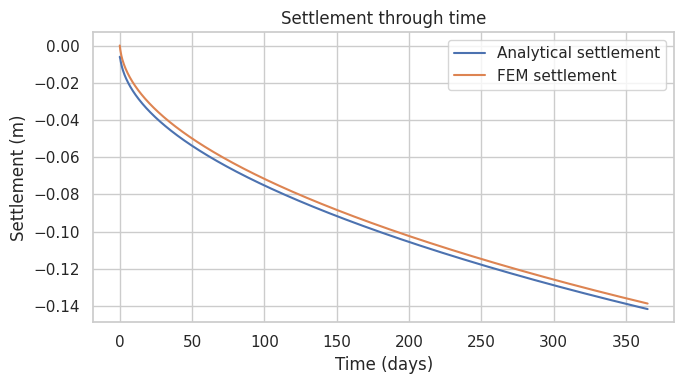

Analytical Settlement 365.0  days: 0.1417 m
Total Settlement: 365.0 days 0.1387 m
Total Settlement: 0.2500 m


In [4]:
analytical_settlement = analytical_cdata.mean(axis=1) * total_settlement

plt.figure(figsize=(7, 4))
plt.plot(time_days, -analytical_settlement, label="Analytical settlement")
plt.plot(time_days, -fem_settlement_hist,   label="FEM settlement")
plt.xlabel("Time (days)")
plt.ylabel("Settlement (m)")
plt.title("Settlement through time")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Analytical Settlement {Final_time / (60*60*24)}  days: {analytical_settlement[-1]:.4f} m")
print(f"Total Settlement: {Final_time / (60*60*24)} days {fem_settlement_hist[-1]:.4f} m")
print(f"Total Settlement: {total_settlement:.4f} m")

## Mesh Convergence

Error taken at the final time step so that early-time Gibbs oscillations do not dominate the trend.


 Mesh size: 5 Done
 Mesh size: 10 Done
 Mesh size: 20 Done
 Mesh size: 40 Done
 Mesh size: 60 Done
 Mesh size: 80 Done


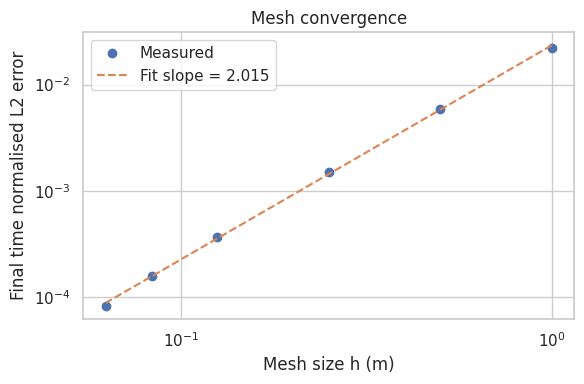

In [5]:
mesh_sizes     = np.array([5, 10, 20, 40, 60, 80], dtype=int)
T_conv         = 50 * 24 * 60 * 60
time_steps_conv = 5000
N_terms_conv   = 200

mesh_h  = H / mesh_sizes # mesh is uniform so its ok
mesh_l2 = []

for nx in mesh_sizes:
    _, fem_u, _ = Get_terzaghi1D_FEA(H, nx, load, T_conv, time_steps_conv, Cv, 0.0, Mv, True)
    _, an_u, _, _ = Get_terzaghi1d_Analytical(H, nx, load, T_conv, time_steps_conv, Cv, N_terms_conv)
    err  = fem_u[-1, :] - an_u[-1, :]
    dz   = H / (len(err) - 1)
    l2   = np.sqrt(np.sum(err**2) * dz)
    ref  = np.sqrt(np.sum(an_u[0, :]**2) * dz)
    mesh_l2.append(l2 / (ref + 1e-30))
    print(f" Mesh size: {nx} Done")

mesh_l2 = np.asarray(mesh_l2)
p_m, logC_m = np.polyfit(np.log(mesh_h), np.log(mesh_l2), 1)
fit_m = np.exp(logC_m) * mesh_h**p_m

plt.figure(figsize=(6, 4))
plt.loglog(mesh_h, mesh_l2, "o",  label="Measured")
plt.loglog(mesh_h, fit_m,   "--", label=f"Fit slope = {p_m:.3f}")
plt.xlabel("Mesh size h (m)")
plt.ylabel("Final time normalised L2 error")
plt.title("Mesh convergence")
plt.legend()
plt.tight_layout()
plt.show()

## Time-Step Convergence


100: done
200: done
400: done
800: done
1600: done


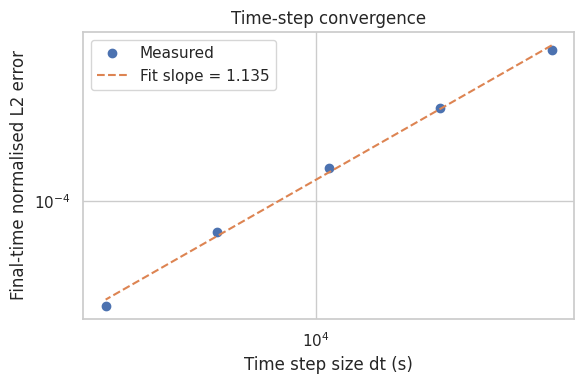

In [6]:
num_fixed = 200
time_steps_list = np.array([100, 200, 400, 800, 1600], dtype=int)
dt_list = T_conv / time_steps_list
time_l2 = []

for n_steps in time_steps_list:
    _, fem_u, _ = Get_terzaghi1D_FEA(H, num_fixed, load, T_conv, n_steps, Cv, 0.0, Mv, True)
    _, an_u, _, _ = Get_terzaghi1d_Analytical(H, num_fixed, load, T_conv, n_steps, Cv, N_terms_conv)
    err  = fem_u[-1, :] - an_u[-1, :]
    dz   = H / (len(err) - 1)
    l2   = np.sqrt(np.sum(err**2) * dz)
    ref  = np.sqrt(np.sum(an_u[0, :]**2) * dz)
    time_l2.append(l2 / (ref + 1e-30))
    print(f"{n_steps}: done")

time_l2 = np.asarray(time_l2)
p_t, logC_t = np.polyfit(np.log(dt_list), np.log(time_l2), 1)
fit_t = np.exp(logC_t) * dt_list**p_t

plt.figure(figsize=(6, 4))
plt.loglog(dt_list, time_l2, "o",  label="Measured")
plt.loglog(dt_list, fit_t,   "--", label=f"Fit slope = {p_t:.3f}")
plt.xlabel("Time step size dt (s)")
plt.ylabel("Final-time normalised L2 error")
plt.title("Time-step convergence")
plt.legend()
plt.tight_layout()
plt.show()